
# Clustering (Unsupervised Learning)

## 1. Clustering là gì?

**Clustering** là một kỹ thuật trong **Unsupervised Learning** dùng để **gom các điểm dữ liệu giống nhau vào cùng một nhóm**.

Nói đơn giản:

> **Clustering = chia dữ liệu thành các nhóm tự nhiên, khi dữ liệu ban đầu không có nhãn.**

Ví dụ: ta có dữ liệu khách hàng gồm tuổi, thu nhập, điểm chi tiêu.  
Nhưng ta **không biết trước** ai là khách hàng VIP, ai là khách hàng tiết kiệm, ai là khách hàng tiềm năng.

Clustering sẽ tự tìm pattern trong dữ liệu và chia khách hàng thành các nhóm khác nhau.



## 2. Unsupervised Learning là gì?

Trong **Supervised Learning**, dữ liệu có nhãn.

Ví dụ:

| Email | Label |
|---|---|
| "Win money now" | Spam |
| "Meeting at 9AM" | Not Spam |

Model học từ dữ liệu đã có đáp án.

Trong **Unsupervised Learning**, dữ liệu **không có nhãn**.

Ví dụ:

| Customer | Age | Income | Spending Score |
|---|---:|---:|---:|
| A | 21 | 3000 | 80 |
| B | 45 | 7000 | 20 |
| C | 23 | 3200 | 75 |

Không có cột `Label`.  
Model phải tự tìm cấu trúc ẩn trong dữ liệu.



## 3. Ý tưởng chính của Clustering

Clustering dựa trên ý tưởng:

> Những điểm dữ liệu **gần nhau** hoặc **giống nhau** sẽ được xếp vào cùng một cluster.

Ví dụ trực giác:

```text
Cluster 1:      x x x
                x x

Cluster 2:                  o o o
                             o o

Cluster 3:        + + +
                  + +
```

Model sẽ hiểu rằng các điểm `x`, `o`, `+` tạo thành 3 nhóm khác nhau.


## 4. Công thức khoảng cách Euclidean Distance

Một cách phổ biến để đo độ giống nhau là dùng **Euclidean Distance**.

Công thức:

$$
d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
$$

Trong đó:

- $A(x_1, y_1)$: điểm thứ nhất
- $B(x_2, y_2)$: điểm thứ hai
- $d(A, B)$: khoảng cách giữa hai điểm

Ví dụ:

$$
A = (2, 3)
$$

$$
B = (5, 7)
$$

$$
d(A, B) = \sqrt{(5 - 2)^2 + (7 - 3)^2}
$$

$$
d(A, B) = \sqrt{3^2 + 4^2}
$$

$$
d(A, B) = \sqrt{9 + 16}
$$

$$
d(A, B) = 5
$$

Nếu khoảng cách càng nhỏ, hai điểm càng giống nhau.

In [1]:

import numpy as np

A = np.array([2, 3])
B = np.array([5, 7])

distance = np.sqrt((B[0] - A[0])**2 + (B[1] - A[1])**2)

print("Khoảng cách Euclidean giữa A và B là:", distance)


Khoảng cách Euclidean giữa A và B là: 5.0



## 5. Các thuật toán Clustering phổ biến

### 5.1. K-Means Clustering

**K-Means** là một trong những thuật toán clustering phổ biến nhất.

Ý tưởng:

1. Chọn số cụm \(K\)
2. Tạo \(K\) tâm cụm, gọi là **centroids**
3. Gán mỗi điểm dữ liệu vào centroid gần nhất
4. Cập nhật lại centroid bằng trung bình của các điểm trong cụm
5. Lặp lại đến khi các cụm ổn định

Ví dụ:

Nếu chọn:

\[
K = 3
\]

thì model sẽ cố gắng chia dữ liệu thành **3 cụm**.



## 6. Demo 1: Tạo dữ liệu giả lập để học Clustering

Ở demo này, ta tạo dữ liệu 2 chiều để dễ nhìn trên biểu đồ.

Mỗi điểm dữ liệu có:

- Feature 1
- Feature 2

Model không biết trước label thật.  
Nhiệm vụ của K-Means là tự chia dữ liệu thành các nhóm.


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Tạo dữ liệu giả lập gồm 300 điểm, chia tự nhiên thành 3 nhóm
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])

df.head()


,Feature_1,Feature_2
0,-7.338988,-7.729954
1,-7.740041,-7.264665
2,-1.686653,7.793442
3,4.422198,3.071947
4,-8.917752,-7.888196


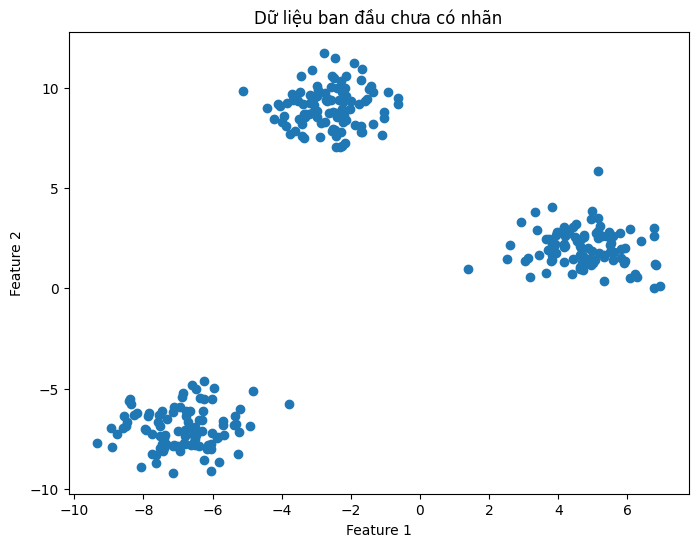

In [3]:

plt.figure(figsize=(8, 6))
plt.scatter(df["Feature_1"], df["Feature_2"])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dữ liệu ban đầu chưa có nhãn")
plt.show()



## 7. Huấn luyện K-Means

Ta chọn:

\[
K = 3
\]

Tức là yêu cầu model chia dữ liệu thành 3 cụm.


In [4]:

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Huấn luyện model và dự đoán cluster cho từng điểm
clusters = kmeans.fit_predict(df)

df["Cluster"] = clusters

df.head()


,Feature_1,Feature_2,Cluster
0,-7.338988,-7.729954,1
1,-7.740041,-7.264665,1
2,-1.686653,7.793442,0
3,4.422198,3.071947,2
4,-8.917752,-7.888196,1


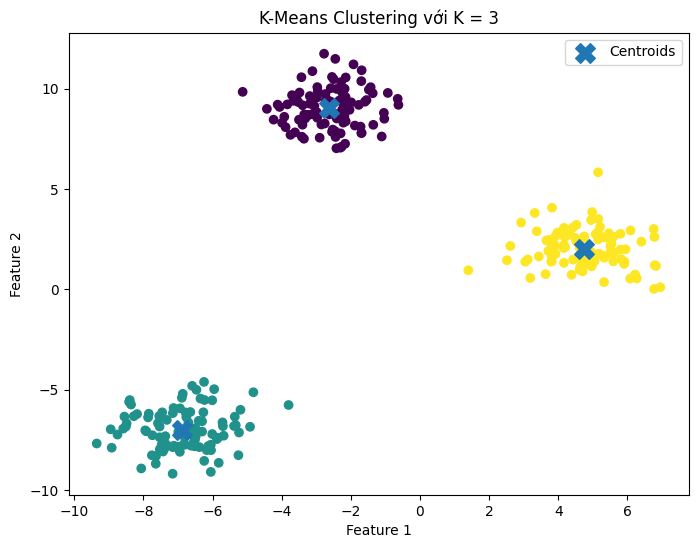

In [5]:

plt.figure(figsize=(8, 6))
plt.scatter(df["Feature_1"], df["Feature_2"], c=df["Cluster"])

# Lấy tọa độ tâm cụm
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    marker="X",
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering với K = 3")
plt.legend()
plt.show()



## 8. Centroid là gì?

**Centroid** là tâm của một cluster.

Ví dụ, nếu một cluster có nhiều điểm dữ liệu, centroid là vị trí trung bình của các điểm đó.

K-Means hoạt động bằng cách:

- Tìm centroid
- Gán điểm dữ liệu vào centroid gần nhất
- Cập nhật lại centroid
- Lặp lại quá trình này

Centroid không nhất thiết phải là một điểm dữ liệu thật trong dataset.


In [6]:

print("Tọa độ các centroid:")
print(centroids)


Tọa độ các centroid:
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]



## 9. Vấn đề quan trọng: Chọn K như thế nào?

Trong K-Means, ta phải chọn trước số cụm \(K\).

Nếu chọn sai \(K\), kết quả clustering có thể không tốt.

Ví dụ:

- \(K = 2\): có thể gom thiếu nhóm
- \(K = 10\): có thể chia quá nhỏ
- \(K = 3\): trong ví dụ này là hợp lý

Một cách phổ biến để chọn \(K\) là dùng **Elbow Method**.



## 10. Elbow Method

**Elbow Method** dùng giá trị **inertia** để đánh giá.

Inertia là tổng khoảng cách bình phương từ mỗi điểm đến centroid của cluster nó thuộc về.

Ý tưởng:

- K càng lớn, inertia càng giảm
- Nhưng đến một điểm nào đó, tăng K thêm không giúp giảm inertia nhiều nữa
- Điểm gấp khúc đó gọi là **elbow**
- Ta chọn K tại vị trí elbow

Ví dụ hình dung:

```text
Inertia cao |
            |
            |\
            | \
            |  \
            |   \__
            |      \__
            |___________ K
                  ^
                Elbow
```


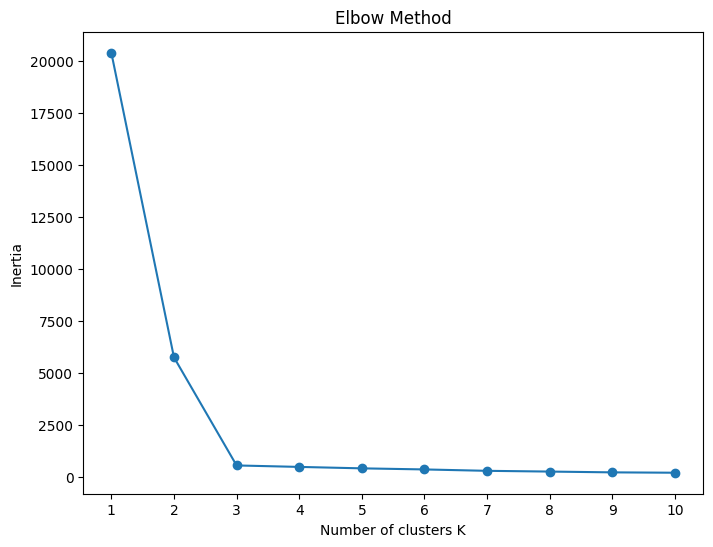

In [7]:

inertias = []

K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df[["Feature_1", "Feature_2"]])
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(K_range)
plt.show()



## 11. Silhouette Score

Ngoài Elbow Method, ta có thể dùng **Silhouette Score**.

Silhouette Score đo xem:

- Một điểm dữ liệu có gần các điểm trong cùng cluster không
- Và có xa các điểm ở cluster khác không

Giá trị nằm trong khoảng:

\[
-1 \leq \text{Silhouette Score} \leq 1
\]

Cách hiểu:

| Score | Ý nghĩa |
|---:|---|
| Gần 1 | Cluster rất tốt |
| Gần 0 | Các cluster bị chồng lấn |
| Nhỏ hơn 0 | Có thể điểm bị gán sai cluster |

Score càng cao thì clustering càng tốt.


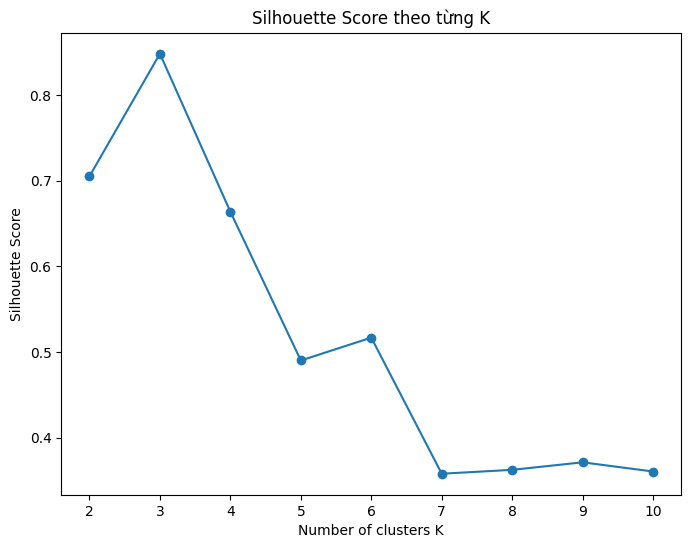

In [8]:

from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(df[["Feature_1", "Feature_2"]])
    score = silhouette_score(df[["Feature_1", "Feature_2"]], labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 6))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score theo từng K")
plt.xticks(K_range)
plt.show()


In [ ]:

best_k = list(K_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("K tốt nhất theo Silhouette Score:", best_k)
print("Silhouette Score tốt nhất:", best_score)



## 12. Demo 2: Customer Segmentation

Bây giờ ta demo tình huống thực tế hơn: **phân nhóm khách hàng**.

Giả sử ta có dữ liệu khách hàng gồm:

- Annual Income
- Spending Score

Mục tiêu:

> Chia khách hàng thành các nhóm có hành vi tài chính/chi tiêu giống nhau.


In [9]:

# Tạo dữ liệu khách hàng giả lập
customer_data = pd.DataFrame({
    "Annual_Income": [15, 16, 17, 18, 20, 22, 25, 28, 30, 32,
                      60, 62, 65, 67, 70, 72, 75, 78, 80, 82,
                      90, 92, 95, 97, 100, 102, 105, 108, 110, 115],
    "Spending_Score": [80, 82, 85, 78, 88, 90, 75, 70, 72, 68,
                       40, 42, 38, 45, 50, 48, 52, 55, 58, 54,
                       15, 18, 20, 22, 25, 28, 30, 26, 24, 20]
})

customer_data.head()


,Annual_Income,Spending_Score
0,15,80
1,16,82
2,17,85
3,18,78
4,20,88


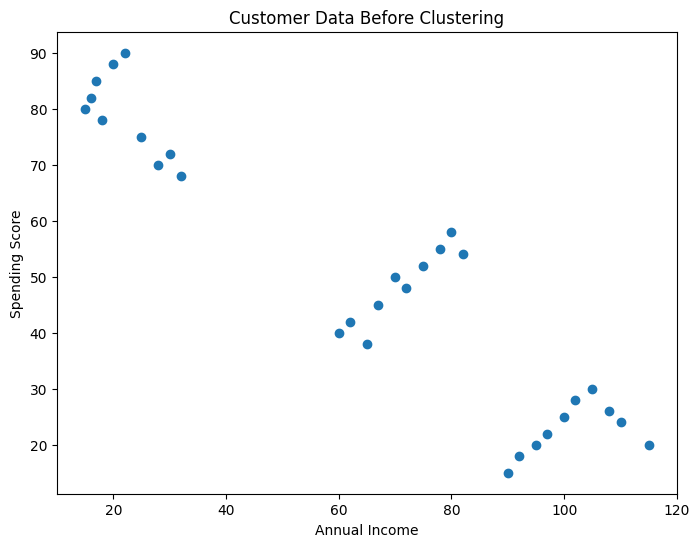

In [10]:

plt.figure(figsize=(8, 6))
plt.scatter(customer_data["Annual_Income"], customer_data["Spending_Score"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data Before Clustering")
plt.show()


## 13. Scale dữ liệu trước khi Clustering

Với K-Means, khoảng cách giữa các điểm rất quan trọng.

Nếu một feature có giá trị quá lớn so với feature khác, nó có thể chi phối kết quả clustering.

Vì vậy, ta thường dùng **StandardScaler**.

Công thức chuẩn hóa:

$$
z = \frac{x - \mu}{\sigma}
$$

Trong đó:

- $x$: giá trị ban đầu
- $\mu$: giá trị trung bình
- $\sigma$: độ lệch chuẩn
- $z$: giá trị sau khi chuẩn hóa

In [11]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

customer_scaled = scaler.fit_transform(customer_data)

customer_scaled[:5]


array([[-1.49848259,  1.2686671 ],
       [-1.46847292,  1.35305737],
       [-1.43846326,  1.47964278],
       [-1.4084536 ,  1.18427682],
       [-1.34843427,  1.60622818]])

In [12]:

customer_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

customer_clusters = customer_kmeans.fit_predict(customer_scaled)

customer_data["Cluster"] = customer_clusters

customer_data.head()


,Annual_Income,Spending_Score,Cluster
0,15,80,1
1,16,82,1
2,17,85,1
3,18,78,1
4,20,88,1


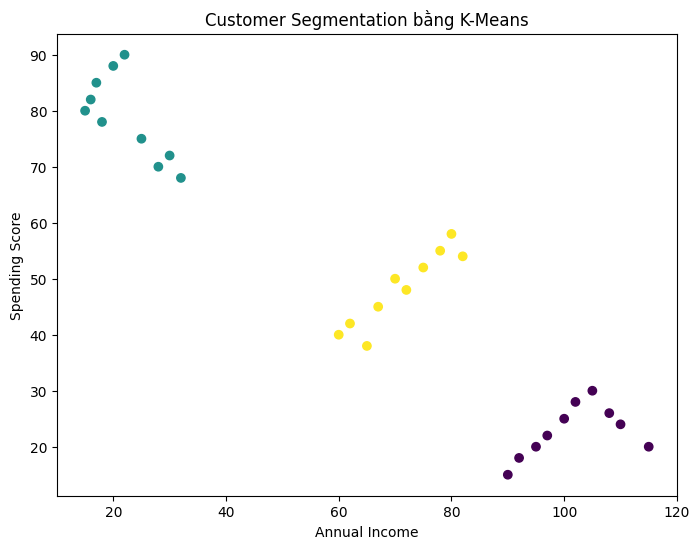

In [13]:

plt.figure(figsize=(8, 6))
plt.scatter(
    customer_data["Annual_Income"],
    customer_data["Spending_Score"],
    c=customer_data["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation bằng K-Means")
plt.show()



## 14. Diễn giải kết quả Customer Segmentation

Sau khi clustering, ta cần xem đặc điểm trung bình của từng cluster.

Lưu ý quan trọng:

> Cluster 0, Cluster 1, Cluster 2 chỉ là tên máy tự đặt.  
> Con người phải nhìn vào đặc điểm từng nhóm để đặt tên có ý nghĩa.


In [14]:

cluster_summary = customer_data.groupby("Cluster")[["Annual_Income", "Spending_Score"]].mean()

cluster_summary


,Annual_Income,Spending_Score
Cluster,,
0,101.4,22.8
1,22.3,78.8
2,71.1,48.2



Ví dụ diễn giải:

| Nhóm | Đặc điểm có thể đặt tên |
|---|---|
| Thu nhập thấp, chi tiêu cao | Young high spenders / Potential growth customers |
| Thu nhập trung bình, chi tiêu trung bình | Stable customers |
| Thu nhập cao, chi tiêu thấp | Wealthy but conservative customers |

Trong thực tế, tên nhóm phụ thuộc vào dataset và business context.



## 15. Hierarchical Clustering

**Hierarchical Clustering** là thuật toán clustering tạo ra cấu trúc phân cấp dạng cây.

Có hai hướng chính:

### Agglomerative Clustering

Bắt đầu từ từng điểm riêng lẻ, sau đó gộp dần lại thành cụm lớn hơn.

```text
A   B   C   D
 \ /     \ /
 AB       CD
   \     /
    ABCD
```

### Divisive Clustering

Bắt đầu từ một cụm lớn, sau đó chia nhỏ dần.

Hierarchical Clustering hữu ích khi ta muốn xem dữ liệu được chia nhóm theo nhiều cấp độ.


In [15]:

from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical.fit_predict(customer_scaled)

customer_data["Hierarchical_Cluster"] = hierarchical_labels

customer_data.head()


,Annual_Income,Spending_Score,Cluster,Hierarchical_Cluster
0,15,80,1,0
1,16,82,1,0
2,17,85,1,0
3,18,78,1,0
4,20,88,1,0


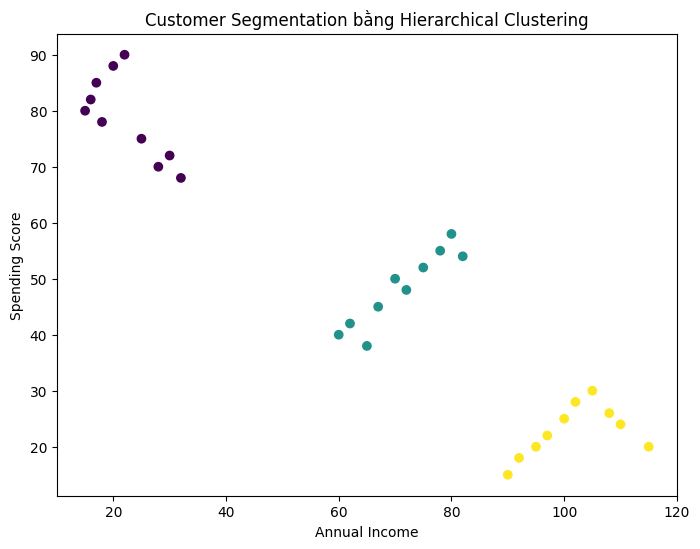

In [16]:

plt.figure(figsize=(8, 6))
plt.scatter(
    customer_data["Annual_Income"],
    customer_data["Spending_Score"],
    c=customer_data["Hierarchical_Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation bằng Hierarchical Clustering")
plt.show()



## 16. DBSCAN

**DBSCAN** là thuật toán clustering dựa trên mật độ điểm dữ liệu.

DBSCAN phù hợp khi:

- Cluster có hình dạng phức tạp
- Dữ liệu có outliers
- Không muốn chọn trước số cụm K

DBSCAN có hai tham số quan trọng:

| Tham số | Ý nghĩa |
|---|---|
| `eps` | Bán kính để xét hàng xóm |
| `min_samples` | Số điểm tối thiểu để tạo thành vùng mật độ cao |

DBSCAN có thể gán một số điểm là `-1`, nghĩa là **noise/outlier**.


In [17]:

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=3)

dbscan_labels = dbscan.fit_predict(customer_scaled)

customer_data["DBSCAN_Cluster"] = dbscan_labels

customer_data.head()


,Annual_Income,Spending_Score,Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,15,80,1,0,0
1,16,82,1,0,0
2,17,85,1,0,0
3,18,78,1,0,0
4,20,88,1,0,0


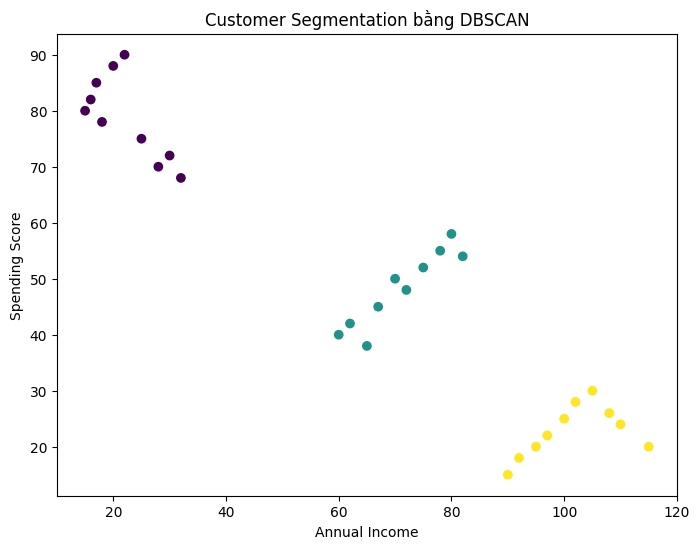

In [18]:

plt.figure(figsize=(8, 6))
plt.scatter(
    customer_data["Annual_Income"],
    customer_data["Spending_Score"],
    c=customer_data["DBSCAN_Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation bằng DBSCAN")
plt.show()



## 17. So sánh các thuật toán Clustering

| Thuật toán | Ưu điểm | Nhược điểm |
|---|---|---|
| K-Means | Nhanh, dễ hiểu, phổ biến | Phải chọn K trước, nhạy với outliers |
| Hierarchical | Có cấu trúc cây, dễ phân tích cấp bậc | Chậm với dataset lớn |
| DBSCAN | Tìm được outliers, không cần chọn K | Khó chọn `eps`, không tốt nếu mật độ cụm khác nhau nhiều |



## 18. Clustering dùng để làm gì?

Clustering được dùng trong nhiều bài toán thực tế:

| Ứng dụng | Ý nghĩa |
|---|---|
| Customer Segmentation | Chia nhóm khách hàng |
| Market Research | Tìm nhóm hành vi tiêu dùng |
| Fraud Detection | Tìm giao dịch bất thường |
| Image Segmentation | Chia vùng trong ảnh |
| Document Clustering | Gom nhóm bài viết cùng chủ đề |
| Recommendation System | Gợi ý sản phẩm/dịch vụ |
| Biology | Phân nhóm gene hoặc bệnh nhân |

Ví dụ trong Finance/Banking:

- Nhóm khách hàng chi tiêu cao
- Nhóm khách hàng tiết kiệm cao
- Nhóm khách hàng rủi ro cao
- Nhóm khách hàng có tiềm năng vay vốn
- Nhóm khách hàng có khả năng rời bỏ dịch vụ



## 19. Clustering khác Classification như thế nào?

| Tiêu chí | Classification | Clustering |
|---|---|---|
| Loại học | Supervised Learning | Unsupervised Learning |
| Có nhãn không? | Có | Không |
| Mục tiêu | Dự đoán class đã biết | Tìm nhóm tự nhiên |
| Ví dụ | Spam / Not Spam | Nhóm khách hàng |
| Output | Label có sẵn | Cluster tự phát hiện |

### Classification

```text
Input: Email
Output: Spam hoặc Not Spam
```

Model đã biết trước có 2 nhãn.

### Clustering

```text
Input: Dữ liệu khách hàng
Output: Cluster 0, Cluster 1, Cluster 2
```

Model tự chia nhóm, sau đó con người mới giải thích ý nghĩa từng cluster.



## 20. Mini Exercise

### Bài 1

Cho dữ liệu khách hàng có hai features:

- Annual Income
- Spending Score

Bạn hãy dùng K-Means để chia thành 4 cụm.

Gợi ý:

```python
model = KMeans(n_clusters=4, random_state=42, n_init=10)
```

---

### Bài 2

Thử thay đổi số cụm:

\[
K = 2, 3, 4, 5
\]

Sau đó quan sát biểu đồ và trả lời:

- K nào có vẻ hợp lý nhất?
- Vì sao?

---

### Bài 3

Dùng Silhouette Score để đánh giá K từ 2 đến 8.

Gợi ý:

```python
from sklearn.metrics import silhouette_score
```

---

### Bài 4

Thử DBSCAN với các giá trị `eps` khác nhau:

```python
eps = 0.3
eps = 0.5
eps = 0.8
eps = 1.0
```

Sau đó quan sát số cluster thay đổi như thế nào.



## 21. Tóm tắt nhanh

Clustering là kỹ thuật học không giám sát dùng để gom dữ liệu thành các nhóm tự nhiên.

Cần nhớ:

- Clustering không cần label
- Dựa trên độ giống nhau hoặc khoảng cách giữa các điểm
- K-Means cần chọn trước số cụm K
- Elbow Method và Silhouette Score giúp chọn K
- DBSCAN có thể phát hiện outliers
- Sau khi model chia cụm, con người cần diễn giải ý nghĩa từng cluster

Câu trả lời ngắn gọn bằng tiếng Anh:

> **Clustering is an unsupervised learning technique used to group similar data points into clusters. Unlike classification, clustering does not require labelled data. The goal is to discover hidden patterns or natural groupings in the dataset.**
